In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys, os, time

sys.path.append(os.path.abspath("../src"))
from SegmentationAndLabelingProblem import SegmentationAndLabeling

## Model setup

Random graph with 2 labels per node, random label and edge weights.

In [2]:
# Generate a graph with randomly weighted connectivity
num_nodes = 8
num_labels = 2

# random model parameters
seed = 12345
np.random.seed(seed)

# alpha_dc
A = np.zeros((num_nodes, num_labels))
A = np.random.uniform(-1, 1, size=(num_nodes, num_labels))
A = np.round(A, 1)

# beta_dc_d'c'
B = np.zeros((num_nodes, num_nodes, num_labels, num_labels))
for d1 in range(num_nodes):
    for d2 in range(d1 + 1, num_nodes):
        for c1 in range(num_labels):
            for c2 in range(num_labels):
                B[d1, d2, c1, c2] = np.random.uniform(-1, 1)
B = np.round(B, 1)

# generate random node positions
np.random.seed(1234)
pos = dict()
for i in range(num_nodes):
    pos[i] = tuple((np.random.randint(640), np.random.randint(480)))

## Max 1 segment

Segmentation and Labeling Problem initialization:
  Number of nodes:  8
  Number of labels:  2
  Maximum number of segments (+1 for suppressed detections):  2


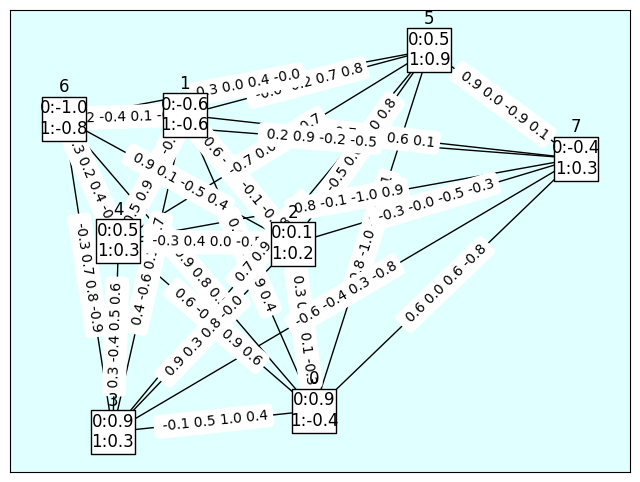

In [3]:
# one-hot encoding requires specifying the maximum number of possible segments (S_max), the optimal number of segments is expected to lie in [1, S_max].
max_num_segments = 1

model = SegmentationAndLabeling(
    num_nodes=num_nodes,
    num_labels=num_labels,
    num_segments=max_num_segments,
    suppress=True,
    pos=pos,
)

fig = plt.figure(figsize=(8, 6), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")
model.draw_graph(
    ax,
    draw_node_labels=True,
    draw_edge_labels=True,
    label_pos=0.5,
    A=A,
    B=B,
)

In [4]:
mdl = model.build_model(A, B, C=10)
mdl.solve()
mdl.print_information()
mdl.print_solution()

Model: Segmentation and Labeling
 - number of variables: 32
   - binary=32, integer=0, continuous=0
 - number of constraints: 0
   - linear=0
 - parameters: defaults
 - objective: minimize quadratic
 - problem type is: MIQP
objective: -4.700
status: OPTIMAL_SOLUTION(2)
  x_0_1_1=1
  x_1_1_0=1
  x_2_1_0=1
  x_3_1_0=1
  x_4_1_0=1
  x_5_0_1=1
  x_6_1_0=1
  x_7_0_0=1


Objective:  -4.700000000000003


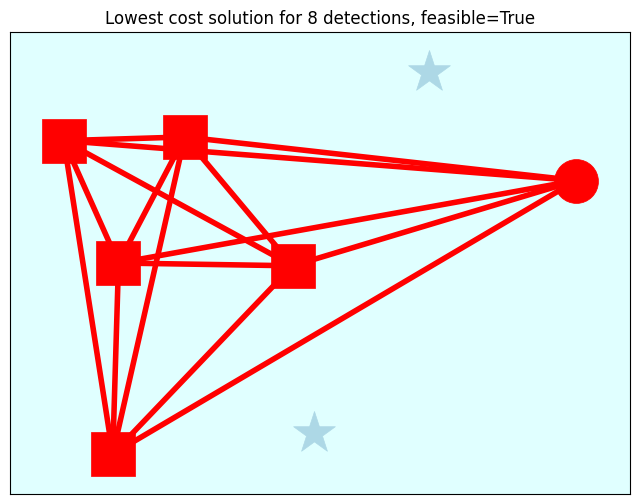

In [5]:
x = np.zeros(mdl.number_of_binary_variables)
for v in mdl.iter_binary_vars():
    x[v.index] = v.solution_value

fig = plt.figure(figsize=(8, 6), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")

model.draw_solution(
    ax,
    x,
    node_size=1000,
    width=4,
    alpha=1.0,
)

print("Objective: ", mdl.objective_value)
feas = model.is_valid(x)
plt.title(f"Lowest cost solution for {num_nodes} detections, feasible={feas}")
plt.show()

## Max 2 segments

In [6]:
# one-hot encoding requires specifying the maximum number of possible segments (S_max), the optimal number of segments is expected to lie in [1, S_max].
max_num_segments = 2

model = SegmentationAndLabeling(
    num_nodes=num_nodes,
    num_labels=num_labels,
    num_segments=max_num_segments,
    suppress=True,
    pos=pos,
)

mdl = model.build_model(A, B, C=10)
mdl.solve()
mdl.print_information()
mdl.print_solution()

Segmentation and Labeling Problem initialization:
  Number of nodes:  8
  Number of labels:  2
  Maximum number of segments (+1 for suppressed detections):  3
Model: Segmentation and Labeling
 - number of variables: 48
   - binary=48, integer=0, continuous=0
 - number of constraints: 0
   - linear=0
 - parameters: defaults
 - objective: minimize quadratic
 - problem type is: MIQP
objective: -6.000
status: OPTIMAL_SOLUTION(2)
  x_0_1_0=1
  x_1_1_1=1
  x_2_0_0=1
  x_3_1_1=1
  x_4_0_0=1
  x_5_0_0=1
  x_6_1_1=1
  x_7_1_1=1


Objective:  -6.000000000000028


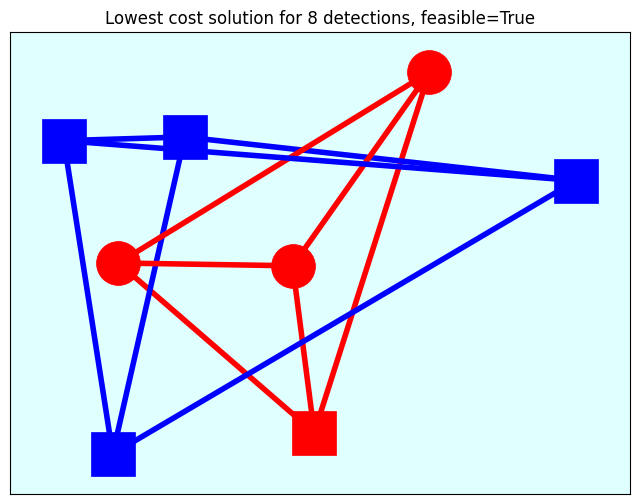

In [7]:
x = np.zeros(mdl.number_of_binary_variables)
for v in mdl.iter_binary_vars():
    x[v.index] = v.solution_value

fig = plt.figure(figsize=(8, 6), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")

model.draw_solution(
    ax,
    x,
    node_size=1000,
    width=4,
    alpha=1.0,
)

print("Objective: ", mdl.objective_value)
feas = model.is_valid(x)
plt.title(f"Lowest cost solution for {num_nodes} detections, feasible={feas}")
plt.show()

## Max 4 segments

In [8]:
# one-hot encoding requires specifying the maximum number of possible segments (S_max), the optimal number of segments is expected to lie in [1, S_max].
max_num_segments = 4

model = SegmentationAndLabeling(
    num_nodes=num_nodes,
    num_labels=num_labels,
    num_segments=max_num_segments,
    suppress=True,
    pos=pos,
)

mdl = model.build_model(A, B, C=10)
mdl.solve()
mdl.print_information()
mdl.print_solution()

Segmentation and Labeling Problem initialization:
  Number of nodes:  8
  Number of labels:  2
  Maximum number of segments (+1 for suppressed detections):  5
Model: Segmentation and Labeling
 - number of variables: 80
   - binary=80, integer=0, continuous=0
 - number of constraints: 0
   - linear=0
 - parameters: defaults
 - objective: minimize quadratic
 - problem type is: MIQP
objective: -6.000
status: OPTIMAL_SOLUTION(2)
  x_0_1_0=1
  x_1_1_3=1
  x_2_0_0=1
  x_3_1_3=1
  x_4_0_0=1
  x_5_0_0=1
  x_6_1_3=1
  x_7_1_3=1


Objective:  -6.000000000000028


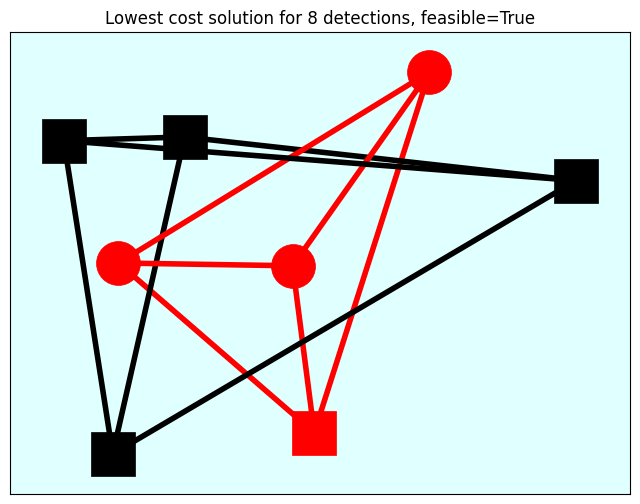

In [9]:
x = np.zeros(mdl.number_of_binary_variables)
for v in mdl.iter_binary_vars():
    x[v.index] = v.solution_value

fig = plt.figure(figsize=(8, 6), frameon=False)
ax = fig.add_subplot(1, 1, 1)  # nrows, ncols, index
ax.set_facecolor("lightcyan")

model.draw_solution(
    ax,
    x,
    node_size=1000,
    width=4,
    alpha=1.0,
)

print("Objective: ", mdl.objective_value)
feas = model.is_valid(x)
plt.title(f"Lowest cost solution for {num_nodes} detections, feasible={feas}")
plt.show()